# Preprocessing: Australian Steam Users Dataset

This notebook is the first step of the recommendation pipeline: **sequence construction**. Its outputs (a cleaned item catalog and per-user interaction sequences) feed into the next stages of the project — item tokenization/embedding, RQ-VAE semantic ID generation, and LLM fine-tuning.

**Datasets**

| Dataset | File | Description |
|---|---|---|
| User interactions | `data/processed_users_items.json` | Steam users and the games they own, with playtime, from the Australian Steam Users dataset |
| Game catalog | `data/93182_steam_games.csv` | Metadata for ~93k Steam store entries (title, description, genres, tags, pricing, etc.) |

**Goals of this notebook**

1. Explore both datasets to understand structure, quality, and coverage.
2. Identify and resolve data quality issues (duplicates, missing values, catalog mismatches).
3. Derive a per-user item interaction sequence and a cleaned, text-enriched item catalog.
4. Export the cleaned artifacts for downstream use.

In [1]:
import json

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

## 1. Load Data

Both files are large (~300 MB CSV, ~750 MB JSON), so we load them once up front and reuse the in-memory frames throughout the notebook.

In [2]:
user_items = pd.read_json("../data/processed_users_items.json")
game_df = pd.read_csv("../data/93182_steam_games.csv", low_memory=False)

print(f"user_items: {user_items.shape[0]:,} rows x {user_items.shape[1]} columns")
print(f"game_df:    {game_df.shape[0]:,} rows x {game_df.shape[1]} columns")

user_items: 88,308 rows x 5 columns
game_df:    93,182 rows x 39 columns


# Part A — Steam Games Catalog (`game_df`)

This dataset provides the item-side metadata (title, description, genres, tags, price, reception) that we will later tokenize and embed to generate semantic IDs. We start by renaming `AppID` to `id` for consistency with the interactions dataset.

In [3]:
game_df = game_df.rename(columns={"AppID": "id"})
game_df["id"] = game_df["id"].astype("Int64").astype(str)

print(game_df.dtypes)
game_df.head(3)

id                                str
Name                              str
Release date                      str
Estimated owners                  str
Peak CCU                        int64
Required age                    int64
Price                         float64
DLC count                       int64
About the game                    str
Supported languages               str
Full audio languages              str
Reviews                           str
Header image                      str
Website                           str
Support url                       str
Support email                     str
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                    str
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements                    int64
Recommendati

,id,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,1424640,余烬,"Oct 3, 2020",20000 - 50000,0,0,3.99,0,'Ashes of war' is an anti war theme adventure ...,['Simplified Chinese'],['Simplified Chinese'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,13639516830@163.com,True,False,False,0,NaN,0,5,7,NaN,44,0,NaN,0,0,0,0,宁夏华夏西部影视城有限公司,宁夏华夏西部影视城有限公司,"Single-player,Family Sharing","Adventure,Casual,Indie,RPG","Sokoban,RPG,Puzzle-Platformer,Exploration,Adve...",https://shared.akamai.steamstatic.com/store_it...,http://video.akamai.steamstatic.com/store_trai...
1,402890,Nyctophilia,"Sep 23, 2015",50000 - 100000,0,0,0.00,0,NYCTOPHILIA Nyctophilia is an 2D psychological...,"['English', 'Russian']","['English', 'Russian']",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,catinjar42@gmail.com,True,False,False,0,NaN,0,196,106,NaN,0,0,NaN,0,0,0,0,Cat In A Jar Games,Cat In A Jar Games,Single-player,"Adventure,Free To Play,Indie","Free to Play,Indie,Adventure,Horror,2D,Pixel G...",https://shared.akamai.steamstatic.com/store_it...,http://video.akamai.steamstatic.com/store_trai...
2,1151740,Prison Princess,"Apr 2, 2020",0 - 20000,0,0,19.99,0,"ABOUT Now nothing more than a phantom, can the...","['English', 'Simplified Chinese', 'Traditional...",['Japanese'],73 – metacritic,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,info@qureate.net,True,False,False,0,NaN,0,264,46,NaN,21,299,This Game may contain content not appropriate ...,0,0,0,0,qureate,qureate,"Single-player,Steam Achievements,Full controll...","Adventure,Indie","Sexual Content,Adventure,Indie,Nudity,Anime,Ma...",https://shared.akamai.steamstatic.com/store_it...,http://video.akamai.steamstatic.com/store_trai...


## A.1 Missing Value Audit

In [4]:
missing_pct = (game_df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_pct[missing_pct > 0]

Score rank          99.99
Metacritic url      95.68
Reviews             88.63
Tags                86.14
Notes               83.54
Estimated owners    82.33
Website             55.30
Support url         52.54
Support email       16.99
Movies               8.21
Publishers           5.69
Categories           5.68
Developers           5.19
Genres               5.15
About the game       5.14
Screenshots          3.02
dtype: float64

**Observations**

- `Score rank` (99.99%), `Metacritic url` (95.7%), `Reviews` free-text (88.6%), `Notes` (83.5%) are almost entirely empty and add little value — candidates for dropping.
- `Tags` (86.1%) and `Estimated owners` (82.3%) are sparse at the *full catalog* level, but this is expected: the catalog holds ~93k store entries while only a small fraction ever appear in our interaction data (see Part C, where we recheck completeness restricted to relevant items).
- Core content fields used for text generation — `Genres` (5.2%), `About the game` (5.1%), `Categories` (5.7%), `Developers`/`Publishers` (~5-6%) — are largely complete.

## A.2 Integrity Checks

In [5]:
print("Duplicate id:", game_df["id"].duplicated().sum())
print("Full-row duplicates:", game_df.duplicated().sum())
print("Empty/missing Name:", (game_df["Name"].isna() | (game_df["Name"].astype(str).str.strip() == "")).sum())
print("Duplicate Name (case-sensitive):", game_df["Name"].duplicated().sum())

Duplicate id: 0


Full-row duplicates: 0
Empty/missing Name: 3
Duplicate Name (case-sensitive): 771


**Observations**

- `id` is a unique key — no duplicate AppIDs, no full-row duplicates.
- 3 rows have an empty `Name`; these carry no usable text and will be dropped.
- 771 titles share a `Name` with another row (remasters, demos, regional re-releases, etc.) — these are distinct products with distinct `id`s, so we leave them as-is.

## A.3 Engagement Column Quality

The catalog carries several columns that *look* like engagement signals (playtime aggregates, Metacritic score, review counts). We check whether they actually carry information.

In [6]:
playtime_cols = [
    "Average playtime forever", "Average playtime two weeks",
    "Median playtime forever", "Median playtime two weeks",
]
for col in playtime_cols:
    print(f"{col}: {(game_df[col] == 0).mean():.1%} zero")

print("\nMetacritic score == 0:", f"{(game_df['Metacritic score'] == 0).mean():.1%}")
print("Positive == 0 & Negative == 0:", f"{((game_df['Positive'] == 0) & (game_df['Negative'] == 0)).mean():.1%}")

Average playtime forever: 100.0% zero
Average playtime two weeks: 100.0% zero
Median playtime forever: 100.0% zero
Median playtime two weeks: 100.0% zero

Metacritic score == 0: 95.7%
Positive == 0 & Negative == 0: 86.2%


**Observations**

- All four playtime columns are **100% zero** — this catalog snapshot carries no usable playtime aggregates at all. They should be dropped rather than treated as genuine "zero engagement."
- `Metacritic score` is 0 for 95.7% of rows (score simply unavailable for most titles, not a real score of 0).
- `Positive`/`Negative` review counts are both zero for 86.2% of rows — reliable only for a minority of well-reviewed titles.

None of these catalog-level engagement columns are trustworthy at scale. Real engagement signal for our use case will instead come from the **interaction dataset** (`user_items`), explored in Part B.

## A.4 Price & Release Date

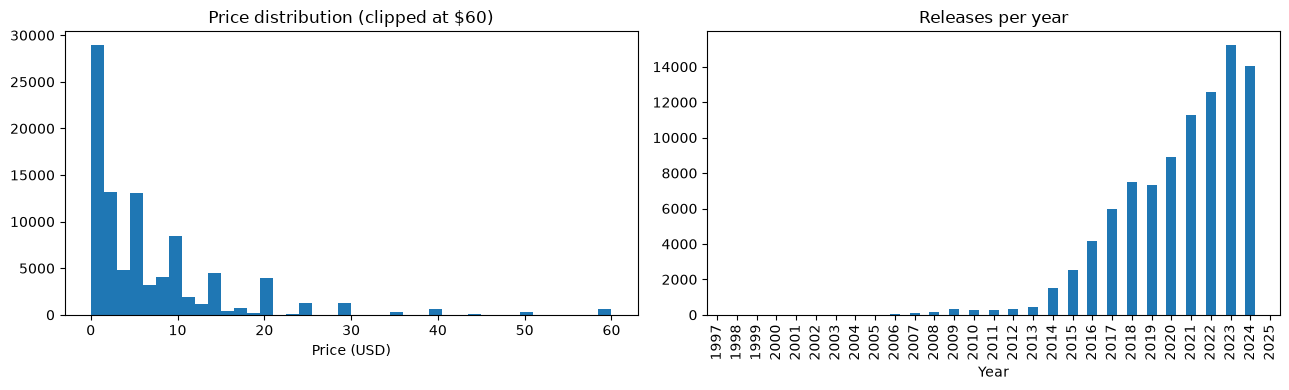

count    93182.000000
mean         7.234385
std         14.074433
min          0.000000
25%          0.990000
50%          3.990000
75%          9.990000
max        999.980000
Name: Price, dtype: float64
Free (price == 0): 19.8%
Unparseable release dates: 0


In [7]:
game_df["release_date_parsed"] = pd.to_datetime(game_df["Release date"], errors="coerce", format="mixed")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(game_df["Price"].clip(upper=60), bins=40)
axes[0].set_title("Price distribution (clipped at $60)")
axes[0].set_xlabel("Price (USD)")

game_df["release_date_parsed"].dt.year.value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Releases per year")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

print(game_df["Price"].describe())
print("Free (price == 0):", f"{(game_df['Price'] == 0).mean():.1%}")
print("Unparseable release dates:", game_df["release_date_parsed"].isna().sum())

**Observations**

- Prices are heavily right-skewed (median $3.99, mean $7.23) with a long tail up to $999.98; 19.8% of titles are free-to-play.
- `Release date` parses cleanly for every row (1997–2025), confirming the format is consistent. Volume grows steeply toward recent years, reflecting Steam's catalog growth (and possibly survivorship/backfill in how this snapshot was built).

## A.5 Estimated Owners

`Estimated owners` is a bucketed range string (e.g. `"20000 - 50000"`). It is only populated for 17.7% of the catalog, but represents a useful coarse popularity signal where available.

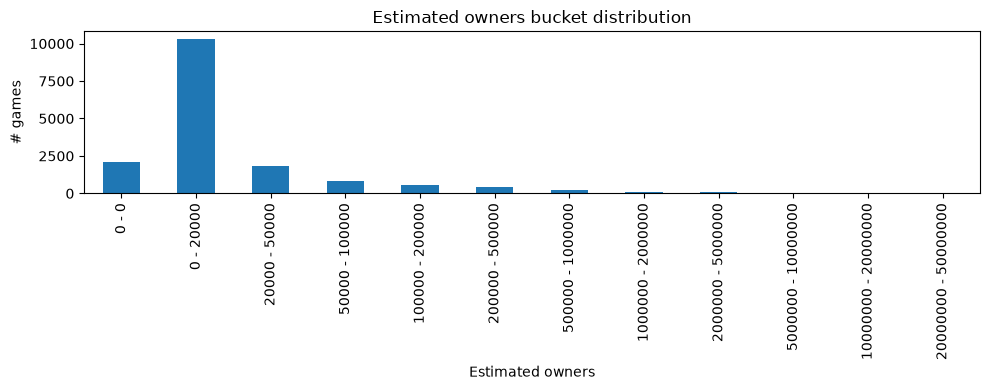

In [8]:
owners_order = [
    "0 - 0", "0 - 20000", "20000 - 50000", "50000 - 100000", "100000 - 200000",
    "200000 - 500000", "500000 - 1000000", "1000000 - 2000000", "2000000 - 5000000",
    "5000000 - 10000000", "10000000 - 20000000", "20000000 - 50000000",
]
game_df["Estimated owners"].value_counts().reindex(owners_order).plot(kind="bar", figsize=(10, 4))
plt.title("Estimated owners bucket distribution")
plt.ylabel("# games")
plt.tight_layout()
plt.show()

**Observation:** among titles with a known bucket, ownership is dominated by the lowest tiers (`0 - 20000`) — expected for a catalog mostly composed of small/indie titles. We will convert this to a numeric midpoint later for use as an optional auxiliary feature.

## A.6 Genres & Tags

`Genres`, `Categories`, and `Tags` are comma-separated strings. We explode them to inspect the most common values — these will be useful signal for the text representation we embed per item.

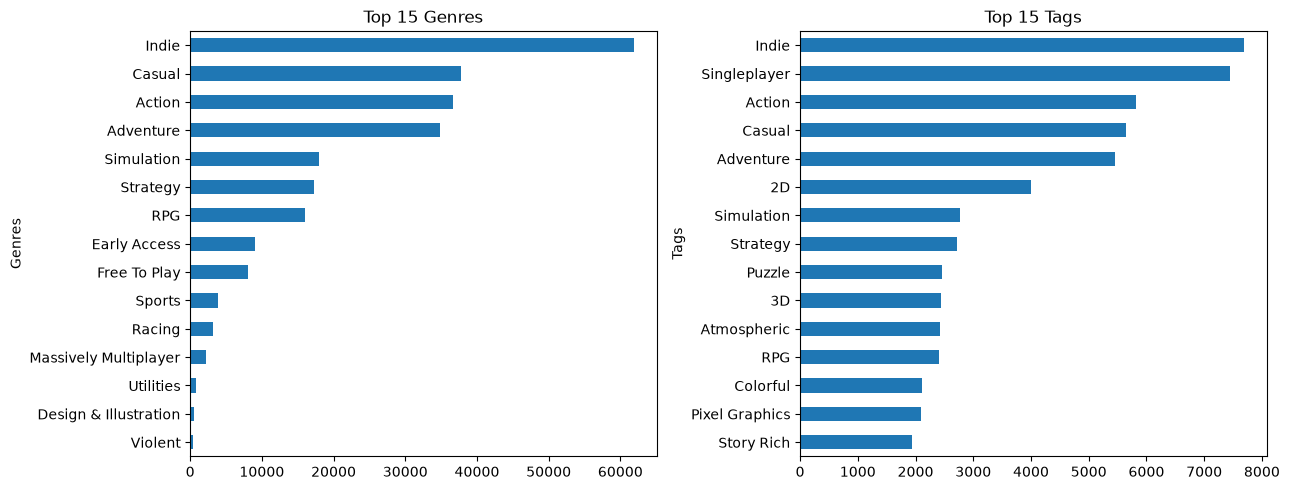

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_genres = game_df["Genres"].dropna().str.split(",").explode().str.strip()
top_genres = top_genres[top_genres != ""].value_counts().head(15)
top_genres.iloc[::-1].plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 15 Genres")

top_tags = game_df["Tags"].dropna().str.split(",").explode().str.strip()
top_tags = top_tags[top_tags != ""].value_counts().head(15)
top_tags.iloc[::-1].plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 15 Tags")

plt.tight_layout()
plt.show()

**Observation:** `Indie`, `Casual`, `Action`, and `Adventure` dominate both genres and tags — consistent with Steam's catalog being long-tail indie-heavy. Genres are a controlled taxonomy (fewer, broader values); tags are community-driven and more granular, making them a richer but noisier signal for text embedding.

## A.7 Description Length (`About the game`)

This free-text field will be a key input for item embeddings, so its length distribution matters for tokenization/truncation decisions downstream.

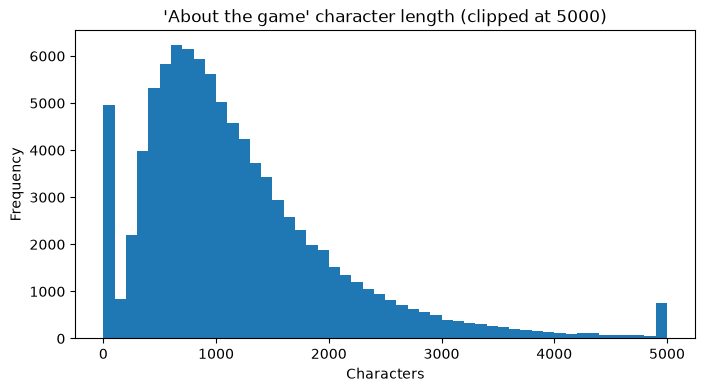

count     93182.000000
mean       1213.879161
std        1203.156543
min           0.000000
25%         603.000000
50%         991.000000
75%        1562.000000
max      131654.000000
Name: About the game, dtype: float64
Empty descriptions: 4790


In [10]:
about_len = game_df["About the game"].fillna("").str.len()

about_len.clip(upper=5000).plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("'About the game' character length (clipped at 5000)")
plt.xlabel("Characters")
plt.show()

print(about_len.describe())
print("Empty descriptions:", (about_len == 0).sum())

**Observation:** median description length is ~991 characters, well within typical embedding-model context limits, so no aggressive truncation strategy is required. 4,790 rows (5.1%) have an empty description and will rely on `Name`/`Genres`/`Tags` alone for their text representation.

# Part B — User-Item Interactions (`user_items`)

Each row is a Steam user; the `items` column holds a **nested list of dicts**, one per owned game, with playtime. This is the source for the interaction sequences we need for sequential recommendation.

In [11]:
print(user_items.dtypes)
print("\nMissing values:\n", user_items.isna().sum())
print("\nSample 'items' entry (first 2 games of first user):")
print(json.dumps(user_items["items"].iloc[0][:2], indent=2))

user_id           str
items_count     int64
steam_id        int64
user_url          str
items          object
dtype: object

Missing values:
 user_id        0
items_count    0
steam_id       0
user_url       0
items          0
dtype: int64

Sample 'items' entry (first 2 games of first user):
[
  {
    "item_id": "10",
    "item_name": "Counter-Strike",
    "playtime_forever": 0,
    "playtime_2weeks": 0
  },
  {
    "item_id": "80",
    "item_name": "Counter-Strike: Condition Zero",
    "playtime_forever": 0,
    "playtime_2weeks": 0
  }
]


Each item dict has four fields: `item_id`, `item_name`, `playtime_forever` (total minutes), `playtime_2weeks` (recent minutes). No columns are null at the top level.

## B.1 Duplicate Users

We check for duplicate `user_id`/`steam_id` — the natural primary keys of this table.

In [12]:
print("Duplicate user_id rows:", user_items["user_id"].duplicated().sum())
print("Duplicate steam_id rows:", user_items["steam_id"].duplicated().sum())

dup_mask = user_items["user_id"].duplicated(keep=False)
dup_groups = user_items.loc[dup_mask].groupby("user_id")
print("Distinct duplicated user_id groups:", dup_groups.ngroups)

# For each duplicated group, check whether it's the same steam_id (re-scraped snapshot)
# and whether the item lists are byte-identical or differ (updated snapshot).
identical, differing, diff_steam_id = 0, 0, 0
for _, g in dup_groups:
    if g["steam_id"].nunique() > 1:
        diff_steam_id += 1
        continue
    lists = [json.dumps(items, sort_keys=True) for items in g["items"]]
    if len(set(lists)) == 1:
        identical += 1
    else:
        differing += 1

print(f"Groups with same steam_id, identical items (pure duplicate rows): {identical}")
print(f"Groups with same steam_id, differing items (re-scraped at different times): {differing}")
print(f"Groups with different steam_id (coincidental username reuse): {diff_steam_id}")

Duplicate user_id rows: 684
Duplicate steam_id rows: 685
Distinct duplicated user_id groups: 673
Groups with same steam_id, identical items (pure duplicate rows): 647
Groups with same steam_id, differing items (re-scraped at different times): 26
Groups with different steam_id (coincidental username reuse): 0


**Observations**

- 673 `user_id` values appear more than once (684 extra rows total), and every duplicated group shares a single `steam_id` — these are re-scraped snapshots of the same account, not different users with a reused handle.
- Of those, 647 groups are byte-identical duplicate rows, and 26 groups have slightly different item lists (the account was captured at two different points in time, so playtime/owned-games differ).
- **Cleaning decision:** deduplicate by `steam_id`, keeping the row with the largest `items_count` (the more complete/more recent snapshot).

## B.2 User Activity (`items_count`)

count    88308.000000
mean        58.351814
std        122.311110
min          0.000000
25%          3.000000
50%         26.000000
75%         73.000000
max       7762.000000
Name: items_count, dtype: float64

Users with items_count == 0 (empty profile): 16805


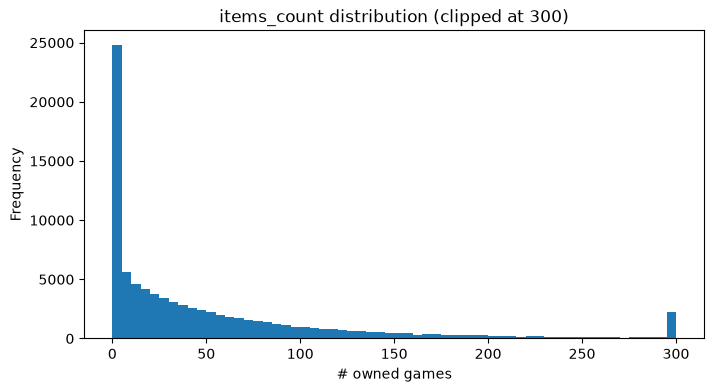

In [13]:
print(user_items["items_count"].describe())
print("\nUsers with items_count == 0 (empty profile):", (user_items["items_count"] == 0).sum())

user_items["items_count"].clip(upper=300).plot(kind="hist", bins=60, figsize=(8, 4))
plt.title("items_count distribution (clipped at 300)")
plt.xlabel("# owned games")
plt.show()

**Observation:** activity is heavily skewed — median user owns 26 games, but 19% of profiles (16,805 users) are empty (`items_count == 0`), likely private/restricted profiles at scrape time. These carry no sequence information and will be dropped in Part D.

## B.3 Flattening Interactions

To analyze item popularity and playtime, we flatten the nested `items` column into a long-format interactions table: one row per (user, item) pair.

In [14]:
records = [
    (steam_id, it["item_id"], it["item_name"], it.get("playtime_forever", 0))
    for steam_id, items in zip(user_items["steam_id"], user_items["items"])
    for it in items
]
interactions_df = pd.DataFrame(records, columns=["steam_id", "item_id", "item_name", "playtime_forever"])

print(f"Total interactions: {len(interactions_df):,}")
print(f"Unique items referenced: {interactions_df['item_id'].nunique():,}")

Total interactions: 5,152,932
Unique items referenced: 10,978


## B.4 Item Popularity (Long Tail)

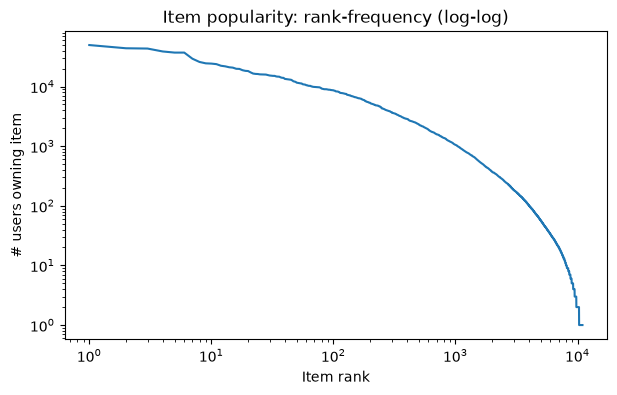

count    10978.000000
mean       469.387138
std       1813.591103
min          1.000000
25%          9.000000
50%         43.000000
75%        222.000000
max      49570.000000
Name: count, dtype: float64

Top 5 most-owned items:
item_id
205790                         Dota 2 Test
730       Counter-Strike: Global Offensive
4000                           Garry's Mod
304930                            Unturned
550                          Left 4 Dead 2
Name: item_name, dtype: str

Items owned by exactly 1 user: 693


In [15]:
item_popularity = interactions_df["item_id"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(np.arange(1, len(item_popularity) + 1), item_popularity.values)
ax.set_xlabel("Item rank")
ax.set_ylabel("# users owning item")
ax.set_title("Item popularity: rank-frequency (log-log)")
plt.show()

print(item_popularity.describe())
print("\nTop 5 most-owned items:")
print(interactions_df.drop_duplicates("item_id").set_index("item_id").loc[item_popularity.head(5).index, "item_name"])
print("\nItems owned by exactly 1 user:", (item_popularity == 1).sum())

**Observation:** item popularity follows the classic long-tail shape typical of implicit-feedback recommendation data — a handful of blockbusters (Counter-Strike, Team Fortress 2, Dota 2 family titles) dominate, while 693 items (6.3% of the catalog referenced in interactions) are owned by only a single user. This long tail is relevant for later stages: rare items will have very little signal for learning good semantic IDs.

## B.5 Playtime Distribution

`playtime_forever` is our only engagement signal, and the one we will use to order each user's item sequence.

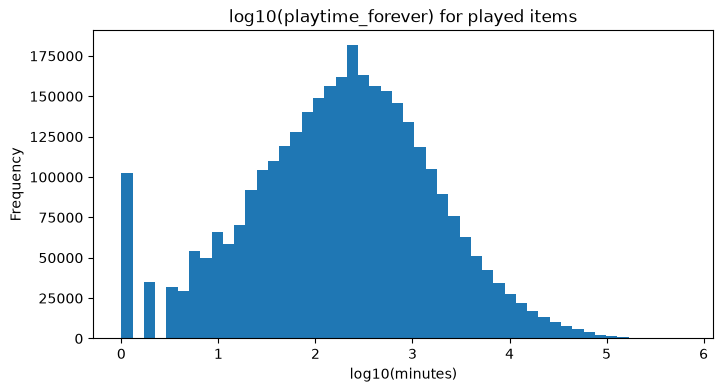

count    5.152932e+06
mean     9.915096e+02
std      5.418329e+03
min      0.000000e+00
25%      0.000000e+00
50%      3.400000e+01
75%      3.550000e+02
max      6.427730e+05
Name: playtime_forever, dtype: float64

Zero playtime (owned but never played): 36.2%


In [16]:
nonzero_playtime = interactions_df.loc[interactions_df["playtime_forever"] > 0, "playtime_forever"]

np.log10(nonzero_playtime).plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("log10(playtime_forever) for played items")
plt.xlabel("log10(minutes)")
plt.show()

print(interactions_df["playtime_forever"].describe())
print("\nZero playtime (owned but never played):", f"{(interactions_df['playtime_forever'] == 0).mean():.1%}")

**Observation:** 36.2% of owned games have zero recorded playtime ("owned but never played" — common with bundles, free weekends, and gifting). Among played games, playtime is log-normal-shaped, spanning minutes to tens of thousands of hours. This confirms `playtime_forever` is a usable, if noisy, engagement proxy.

# Part C — Cross-Dataset Alignment

The interaction sequences are only useful if the referenced items exist in our catalog (`game_df`), since that catalog is what supplies the text used to generate semantic IDs. We check the overlap between the two datasets.

In [17]:
catalog_ids = set(game_df["id"])
interaction_ids = set(interactions_df["item_id"])
missing_ids = interaction_ids - catalog_ids

print("Unique items in interactions:", len(interaction_ids))
print("Present in catalog:", len(interaction_ids & catalog_ids))
print("Missing from catalog:", len(missing_ids))
print("Catalog items never interacted with:", len(catalog_ids - interaction_ids))

missing_interaction_volume = interactions_df["item_id"].isin(missing_ids).mean()
print(f"\nInteraction volume on missing items: {missing_interaction_volume:.2%}")

print("\nSample missing items (present in interactions, absent from catalog):")
print(interactions_df.loc[interactions_df["item_id"].isin(missing_ids), ["item_id", "item_name"]].drop_duplicates().head(10))

Unique items in interactions: 10978
Present in catalog: 8563
Missing from catalog: 2415
Catalog items never interacted with: 84619

Interaction volume on missing items: 19.79%

Sample missing items (present in interactions, absent from catalog):


   item_id                                      item_name
22    2290                                     Final DOOM
23    2300                         DOOM II: Hell on Earth
26    2330                        Quake II: The Reckoning
27    2340                          Quake II: Ground Zero
28    2350                          Quake III: Team Arena
32    9000               Wolfenstein 3D: Spear of Destiny
34    9030  Quake Mission Pack 2: Dissolution of Eternity
35    9040       Quake Mission Pack 1: Scourge of Armagon
38    9070                   DOOM 3: Resurrection of Evil
39    9160                      Master Levels for DOOM II


**Observations**

- Of the 10,978 distinct items referenced in interactions, 8,563 (78%) are present in the catalog and 2,415 (22%) are not — including older classics such as *DOOM II*, *Quake II/III*, and *Wolfenstein 3D* expansions. This mismatch is expected: `93182_steam_games.csv` is a recent store snapshot, while some interacted-with titles have since been delisted, rebranded, or bundled differently.
- Dropping the missing items costs **19.8% of total interaction volume** — non-trivial, but unavoidable without a text description to embed for those items. We accept this trade-off rather than fabricating metadata.

**Decision:** restrict interaction sequences to items present in the catalog.

## C.1 Metadata Completeness on Relevant Items

Part A showed high missingness for `Tags`, `Estimated owners`, and (marginally) `About the game`/`Genres` across the *full* catalog. We recheck those rates restricted to the items that actually appear in interactions — the ones we actually need text for.

In [18]:
relevant_games = game_df[game_df["id"].isin(interaction_ids)]
cols_to_check = ["Estimated owners", "Tags", "About the game", "Genres"]
print(f"Games referenced in interactions and present in catalog: {len(relevant_games):,}\n")
print((relevant_games[cols_to_check].isna().mean() * 100).round(2))

Games referenced in interactions and present in catalog: 8,563

Estimated owners    82.79
Tags                82.89
About the game       0.13
Genres               0.16
dtype: float64


**Observation:** for the 8,563 games we actually need, `About the game` and `Genres` are missing for only ~0.1-0.2% of rows — essentially complete. `Tags` (82.9%) and `Estimated owners` (82.8%) remain sparse even here, confirming these two fields are not reliable enough to depend on and should be treated as optional/auxiliary rather than core text inputs. Missingness in Part A was concentrated almost entirely in catalog items with **no interaction history**, which are irrelevant to this pipeline — we can proceed with confidence in the core text fields.

# Part D — Cleaning & Sequence Construction

We now apply the cleaning decisions made above, in order, to produce the two artifacts this notebook exists to create: a cleaned item catalog and a per-user item sequence table.

## D.1 Deduplicate Users

Keep one row per `steam_id`, preferring the snapshot with the largest `items_count`.

In [19]:
clean_users = (
    user_items.sort_values("items_count")
    .drop_duplicates(subset="steam_id", keep="last")
    .reset_index(drop=True)
)
print(f"Rows before dedup: {len(user_items):,} -> after dedup: {len(clean_users):,}")

Rows before dedup: 88,308 -> after dedup: 87,623


## D.2 Drop Empty Profiles

Users with no owned items (`items_count == 0`) contribute nothing to sequence modeling.

In [20]:
clean_users = clean_users[clean_users["items_count"] > 0].reset_index(drop=True)
print(f"Users with at least one owned item: {len(clean_users):,}")

Users with at least one owned item: 70,911


## D.3 Build Item Sequences

For each user, we build the sequence of catalog-covered items, ordered by `playtime_forever` descending (most-engaged item first).

**Limitation:** the dataset has no interaction timestamps, only cumulative playtime. Ordering by playtime is therefore a **proxy for engagement, not chronology** — it does not reconstruct the true order in which a user acquired or played these games. This is an important caveat for the downstream sequential model: sequences should be treated as an engagement-ranked set rather than a ground-truth chronological history. If timestamped events become available, chronological ordering should be preferred.

In [21]:
def get_item_sequence(items):
    filtered = [it for it in items if it["item_id"] in catalog_ids]
    filtered.sort(key=lambda x: x.get("playtime_forever", 0), reverse=True)
    return [it["item_id"] for it in filtered]

clean_users["item_sequence"] = clean_users["items"].apply(get_item_sequence)
clean_users["sequence_length"] = clean_users["item_sequence"].str.len()

clean_users[["steam_id", "item_sequence", "sequence_length"]].head()

,steam_id,item_sequence,sequence_length
0,76561198280083270,[730],1
1,76561198279896310,[730],1
2,76561198288092724,[304930],1
3,76561198063681152,[],0
4,76561198075637372,[],0


## D.4 Sequence Length Filtering

Sequential/next-item models need at least 2 items per user (one as history, one as target). We also inspect the top of the distribution for likely bots or completionist accounts, which could dominate training if left unweighted.

In [22]:
print(clean_users["sequence_length"].describe())
print(clean_users["sequence_length"].quantile([0.5, 0.9, 0.95, 0.99]))

print("\nsequence_length == 0:", (clean_users["sequence_length"] == 0).sum())
print("sequence_length == 1:", (clean_users["sequence_length"] == 1).sum())
print("sequence_length > 1000 (likely bots/completionists):", (clean_users["sequence_length"] > 1000).sum())

filtered_user_items = clean_users[clean_users["sequence_length"] >= 2].reset_index(drop=True)
filtered_user_items["is_long_tail_user"] = filtered_user_items["sequence_length"] > 1000

print(f"\nUsers retained for sequence modeling: {len(filtered_user_items):,}")

count    70911.000000
mean        57.615589
std        109.193692
min          0.000000
25%         10.000000
50%         31.000000
75%         69.000000
max       6166.000000
Name: sequence_length, dtype: float64
0.50     31.0
0.90    131.0
0.95    192.0
0.99    397.0
Name: sequence_length, dtype: float64

sequence_length == 0: 2337
sequence_length == 1: 2735
sequence_length > 1000 (likely bots/completionists): 105

Users retained for sequence modeling: 65,839


**Observations & decision:** users with 0 or 1 catalog-covered item are dropped — they cannot form a supervised next-item pair. Around 100 accounts have implausibly large sequences (>1,000 items); rather than discarding them outright, we flag them with `is_long_tail_user` so training code can choose to downweight, truncate, or exclude them without losing the underlying data.

## D.5 Final Interaction Sequence Table

In [23]:
filtered_user_items = filtered_user_items[
    ["user_id", "steam_id", "item_sequence", "sequence_length", "is_long_tail_user"]
]

print(f"Final users: {len(filtered_user_items):,}")
print(f"Mean sequence length: {filtered_user_items['sequence_length'].mean():.1f}")
filtered_user_items.head()

Final users: 65,839
Mean sequence length: 62.0


,user_id,steam_id,item_sequence,sequence_length,is_long_tail_user
0,76561198311083545,76561198311083545,"[285900, 370240]",2,False
1,76561198269582107,76561198269582107,"[298630, 304930]",2,False
2,nathanahtan,76561198269064541,"[304930, 211500]",2,False
3,76561198300659277,76561198300659277,"[22200, 334070]",2,False
4,76561198075689207,76561198075689207,"[4000, 215470]",2,False


## D.6 Clean the Item Catalog

We keep the columns useful for text generation and light-weight auxiliary features, and drop what Part A showed to be unreliable or unused: the all-zero playtime aggregates, the near-empty `Score rank`/`Metacritic url`/`Reviews`/`Notes`, and URL/media columns not needed for embeddings.

In [24]:
keep_cols = [
    "id", "Name", "release_date_parsed", "Price", "Estimated owners",
    "About the game", "Genres", "Categories", "Tags",
    "Developers", "Publishers", "Positive", "Negative", "Recommendations",
]
clean_games = game_df[keep_cols].rename(columns={"release_date_parsed": "release_date"}).copy()

# Drop rows with no usable name (empty Name found in A.2)
clean_games = clean_games[clean_games["Name"].fillna("").str.strip() != ""].reset_index(drop=True)
print(f"Catalog rows after dropping empty names: {len(clean_games):,}")

Catalog rows after dropping empty names: 93,179


## D.7 Parse Estimated Owners to a Numeric Midpoint

Converts the bucket string (`"20000 - 50000"`) into a single numeric estimate, easier to use as an auxiliary feature. Left as `NaN` where unavailable rather than imputed, since ~83% of relevant rows lack this field (Part C.1) and imputing a point estimate would fabricate signal.

In [25]:
def parse_owners_midpoint(bucket):
    if pd.isna(bucket):
        return np.nan
    low, high = bucket.split(" - ")
    return (int(low) + int(high)) / 2

clean_games["estimated_owners_mid"] = clean_games["Estimated owners"].apply(parse_owners_midpoint)
clean_games = clean_games.drop(columns=["Estimated owners"])
clean_games[["Name", "estimated_owners_mid"]].dropna().head()

,Name,estimated_owners_mid
0,余烬,35000.0
1,Nyctophilia,75000.0
2,Prison Princess,10000.0
3,Dead In Time,10000.0
4,Panacle: Back To Wild,10000.0


## D.8 Build a Unified Text Field

The next notebook in the pipeline tokenizes and embeds each item. We consolidate the name, genres, categories, tags, and description into a single text field now, so that step can operate on one column instead of re-deriving this logic.

In [26]:
def build_text(row):
    parts = [row["Name"]]
    for col in ["Genres", "Categories", "Tags"]:
        if pd.notna(row[col]):
            parts.append(row[col].replace(",", ", "))
    if pd.notna(row["About the game"]) and row["About the game"].strip():
        parts.append(row["About the game"].strip())
    return ". ".join(parts)

clean_games["text_for_embedding"] = clean_games.apply(build_text, axis=1)

print(clean_games.loc[0, "text_for_embedding"][:500])

余烬. Adventure, Casual, Indie, RPG. Single-player, Family Sharing. Sokoban, RPG, Puzzle-Platformer, Exploration, Adventure, Strategy RPG, Stealth, 3D, Third Person, Hand-drawn, Indie, Casual, War, Cinematic, Singleplayer. 'Ashes of war' is an anti war theme adventure decryption game, the story takes place in the western region during the Anti Japanese war. In the game, the player will control the strong and brave brothers and sisters. After a series of checkpoints, they will fight against the evi


## D.9 Final Catalog

We keep the full cleaned catalog (useful as a candidate pool for recommendation), but also report how much of it is actually exercised by our interaction data, since that subset is what matters for semantic ID training coverage.

In [27]:
filtered_game_df = clean_games
sequence_item_ids = set(item for seq in filtered_user_items["item_sequence"] for item in seq)

print(f"Final catalog size: {len(filtered_game_df):,}")
print(f"Items referenced by cleaned sequences: {len(sequence_item_ids):,}")
filtered_game_df.head()

Final catalog size: 93,179
Items referenced by cleaned sequences: 8,563


,id,Name,release_date,Price,About the game,Genres,Categories,Tags,Developers,Publishers,Positive,Negative,Recommendations,estimated_owners_mid,text_for_embedding
0,1424640,余烬,2020-10-03,3.99,'Ashes of war' is an anti war theme adventure ...,"Adventure,Casual,Indie,RPG","Single-player,Family Sharing","Sokoban,RPG,Puzzle-Platformer,Exploration,Adve...",宁夏华夏西部影视城有限公司,宁夏华夏西部影视城有限公司,5,7,0,35000.0,"余烬. Adventure, Casual, Indie, RPG. Single-play..."
1,402890,Nyctophilia,2015-09-23,0.00,NYCTOPHILIA Nyctophilia is an 2D psychological...,"Adventure,Free To Play,Indie",Single-player,"Free to Play,Indie,Adventure,Horror,2D,Pixel G...",Cat In A Jar Games,Cat In A Jar Games,196,106,0,75000.0,"Nyctophilia. Adventure, Free To Play, Indie. S..."
2,1151740,Prison Princess,2020-04-02,19.99,"ABOUT Now nothing more than a phantom, can the...","Adventure,Indie","Single-player,Steam Achievements,Full controll...","Sexual Content,Adventure,Indie,Nudity,Anime,Ma...",qureate,qureate,264,46,299,10000.0,"Prison Princess. Adventure, Indie. Single-play..."
3,875530,Dead In Time,2018-10-12,7.99,Is a hardcore action with a non-trivial level ...,"Action,Indie","Single-player,Full controller support,Family S...","Action,Indie,Souls-like,Fantasy,Early Access,R...",Zelenov Artem,Zelenov Artem,7,3,0,10000.0,"Dead In Time. Action, Indie. Single-player, Fu..."
4,1835360,Panacle: Back To Wild,2022-03-11,3.99,Panacle: Back to the Wild is a indie card game...,"Indie,Strategy,Early Access","Single-player,Family Sharing","Trading Card Game,Turn-Based Strategy,Lore-Ric...",渡鸦游戏,"渡鸦游戏,电钮组",10,5,0,10000.0,"Panacle: Back To Wild. Indie, Strategy, Early ..."


# Part E — Export Processed Artifacts

Save the cleaned catalog and interaction sequences for the next notebook (item tokenization/embedding).

In [28]:
filtered_game_df.to_parquet("../data/clean_game_catalog.parquet", index=False)
filtered_user_items.to_parquet("../data/clean_user_sequences.parquet", index=False)

print("Saved data/clean_game_catalog.parquet:", filtered_game_df.shape)
print("Saved data/clean_user_sequences.parquet:", filtered_user_items.shape)

Saved data/clean_game_catalog.parquet: (93179, 15)
Saved data/clean_user_sequences.parquet: (65839, 5)


# Summary

**Cleaning applied**

- Deduplicated user records by `steam_id` (673 duplicated accounts collapsed to their most complete snapshot).
- Dropped 16,805 empty profiles and users left with fewer than 2 catalog-covered items.
- Restricted interaction sequences to the 8,563 items also present in the game catalog (accepting a 19.8% loss in interaction volume for items with no available metadata).
- Dropped all-zero playtime aggregates, near-empty columns (`Score rank`, `Metacritic url`, `Reviews`, `Notes`), and URL/media fields from the catalog.
- Parsed `Estimated owners` into a numeric midpoint and built a single `text_for_embedding` field (name + genres + categories + tags + description) per item.
- Flagged (rather than dropped) users with implausibly long sequences (`is_long_tail_user`), so downstream training can decide how to treat them.

**Known limitations for downstream modeling**

- Sequences are ordered by playtime, a proxy for engagement — not a true chronological purchase/play history.
- `Tags` and `Estimated owners` remain sparse (~83% missing) even for relevant items; treat them as optional auxiliary features, not core inputs.
- 22% of interacted-with items have no catalog entry and were dropped; the resulting catalog reflects a recent Steam snapshot, not the full historical set of titles.

**Suggested next steps for training**

- Tokenize/embed `text_for_embedding` per item (next notebook) as input to the RQ-VAE.
- For sequence modeling, consider a leave-one-out or time-agnostic train/val/test split per user (since true chronology is unavailable).
- Apply a minimum-popularity cutoff (e.g. items with < 5 interactions) if semantic ID quality for the extreme long tail proves unstable.
- Consider down-weighting or truncating sequences flagged `is_long_tail_user` to avoid a small number of accounts dominating training.